# Trabajo final: Wine Quality Dataset

**Objetivo del notebook:** unir el EDA y la parte de optimización/selección de modelos, añadiendo selección de variables y curva PR/ROC con punto óptimo de funcionamiento.

> Este notebook está preparado para ejecutarse con el fichero `wine_quality.csv` en la misma carpeta.

## 0. Carga de librerías y configuración general

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from scipy import stats
from scipy.stats import t

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc
)

RANDOM_STATE = 123
DATA_PATH = "wine_quality.csv"

## 1. Carga y comprensión inicial de los datos

In [2]:
wine = pd.read_csv(DATA_PATH, na_values=['', 'NaN', 'NA', 'null', 'N/A'])

print(f"Dimensión de la tabla original: {wine.shape}")
display(wine.head())

print("\nTipos de variables:")
display(wine.dtypes)

print("\nValores perdidos por variable:")
display(wine.isna().sum())

print("\nDuplicados:", wine.duplicated().sum())

print("\nDistribución de quality:")
display(wine['quality'].value_counts().sort_index())

Dimensión de la tabla original: (6497, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Tipos de variables:


,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64



Valores perdidos por variable:


,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0



Duplicados: 1179

Distribución de quality:


,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


## 2. Limpieza básica y definición del problema predictivo

In [3]:
datos = wine.copy()

# Eliminamos duplicados completos, igual que en los trabajos previos.
duplicados = datos.duplicated().sum()
datos = datos.drop_duplicates().reset_index(drop=True)

# La variable respuesta se trata como clasificación multiclase.
datos['quality'] = datos['quality'].astype(int)

X = datos.drop(columns='quality')
y = datos['quality']

variables_numericas = X.select_dtypes(include='number').columns.tolist()
classes = np.sort(y.unique())

print(f"Filas duplicadas eliminadas: {duplicados}")
print(f"Dimensión tras limpieza: {datos.shape}")
print(f"Número de clases de quality: {len(classes)} -> {classes}")
print("Variables predictoras numéricas:")
print(variables_numericas)

Filas duplicadas eliminadas: 1179
Dimensión tras limpieza: (5318, 12)
Número de clases de quality: 7 -> [3 4 5 6 7 8 9]
Variables predictoras numéricas:
['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 3. Análisis Exploratorio de Datos (EDA)

Este bloque reúne el código principal del EDA ya realizado.

In [4]:
display(datos[variables_numericas + ['quality']].describe().T)

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,5318.0,7.215523,1.319777,3.80000,6.4000,7.00000,7.70000,15.90000
volatile_acidity,5318.0,0.344171,0.168264,0.08000,0.2300,0.30000,0.41000,1.58000
citric_acid,5318.0,0.318522,0.147177,0.00000,0.2400,0.31000,0.40000,1.66000
residual_sugar,5318.0,5.049605,4.500645,0.60000,1.8000,2.70000,7.50000,65.80000
chlorides,5318.0,0.056700,0.036865,0.00900,0.0380,0.04700,0.06600,0.61100
free_sulfur_dioxide,5318.0,30.030463,17.804365,1.00000,16.0000,28.00000,41.00000,289.00000
total_sulfur_dioxide,5318.0,114.107747,56.783848,6.00000,74.0000,116.00000,153.75000,440.00000
density,5318.0,0.994536,0.002966,0.98711,0.9922,0.99466,0.99677,1.03898
pH,5318.0,3.224639,0.160403,2.72000,3.1100,3.21000,3.33000,4.01000
sulphates,5318.0,0.533402,0.149753,0.22000,0.4300,0.51000,0.60000,2.00000


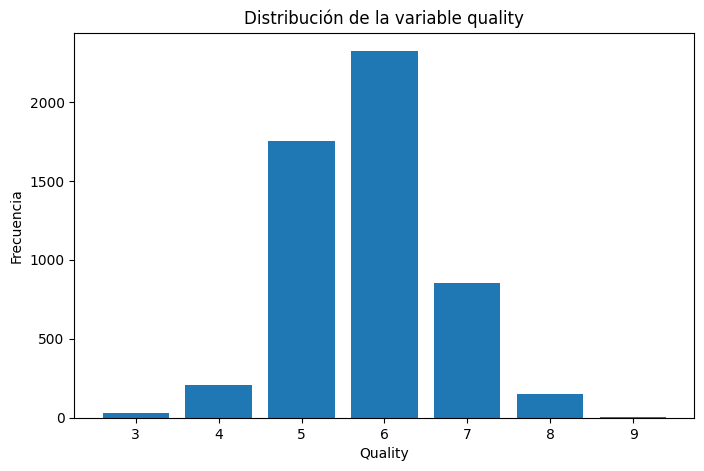

,Frecuencia,Porcentaje (%)
quality,,
3,30,0.56
4,206,3.87
5,1751,32.93
6,2323,43.68
7,855,16.08
8,148,2.78
9,5,0.09


In [5]:
frecuencias_quality = datos['quality'].value_counts().sort_index()
porcentajes_quality = datos['quality'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))
plt.bar(frecuencias_quality.index.astype(str), frecuencias_quality.values)
plt.title("Distribución de la variable quality")
plt.xlabel("Quality")
plt.ylabel("Frecuencia")
plt.show()

tabla_quality = pd.DataFrame({
    'Frecuencia': frecuencias_quality,
    'Porcentaje (%)': porcentajes_quality.round(2)
})
display(tabla_quality)

La variable respuesta `quality` presenta un claro desbalanceo entre clases. La mayoría de los vinos se concentran en las calidades 5 y 6, mientras que las clases extremas, especialmente 3 y 9, tienen una frecuencia muy reducida. Esto puede dificultar que los modelos aprendan correctamente dichas clases minoritarias. Por este motivo, además de la accuracy, se utiliza la métrica F1-macro, ya que esta da el mismo peso a todas las clases y permite evaluar mejor el rendimiento global en problemas multiclase desbalanceados.

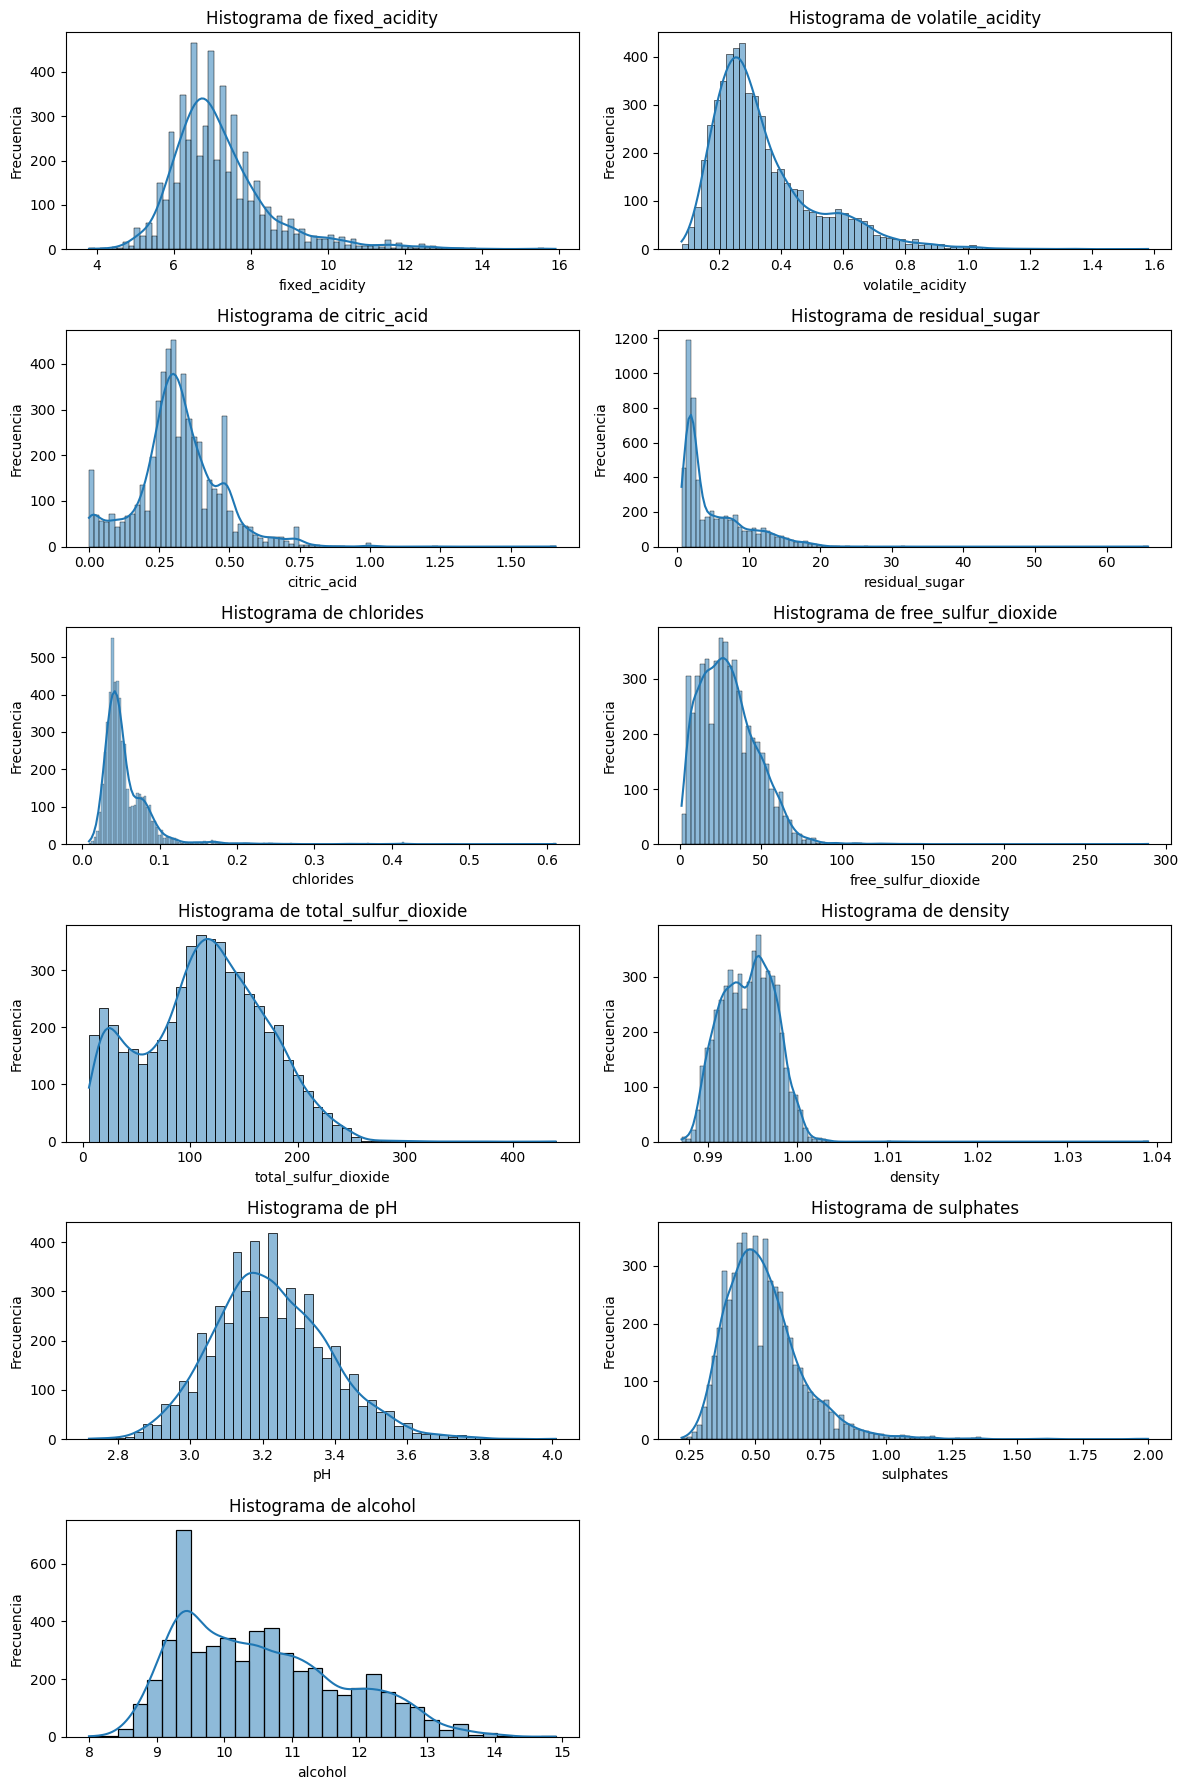

In [6]:
n = len(variables_numericas)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 18))
axes = axes.flatten()

for i, columna in enumerate(variables_numericas):
    sns.histplot(datos[columna], kde=True, ax=axes[i], color='C0')
    axes[i].set_title(f'Histograma de {columna}')
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

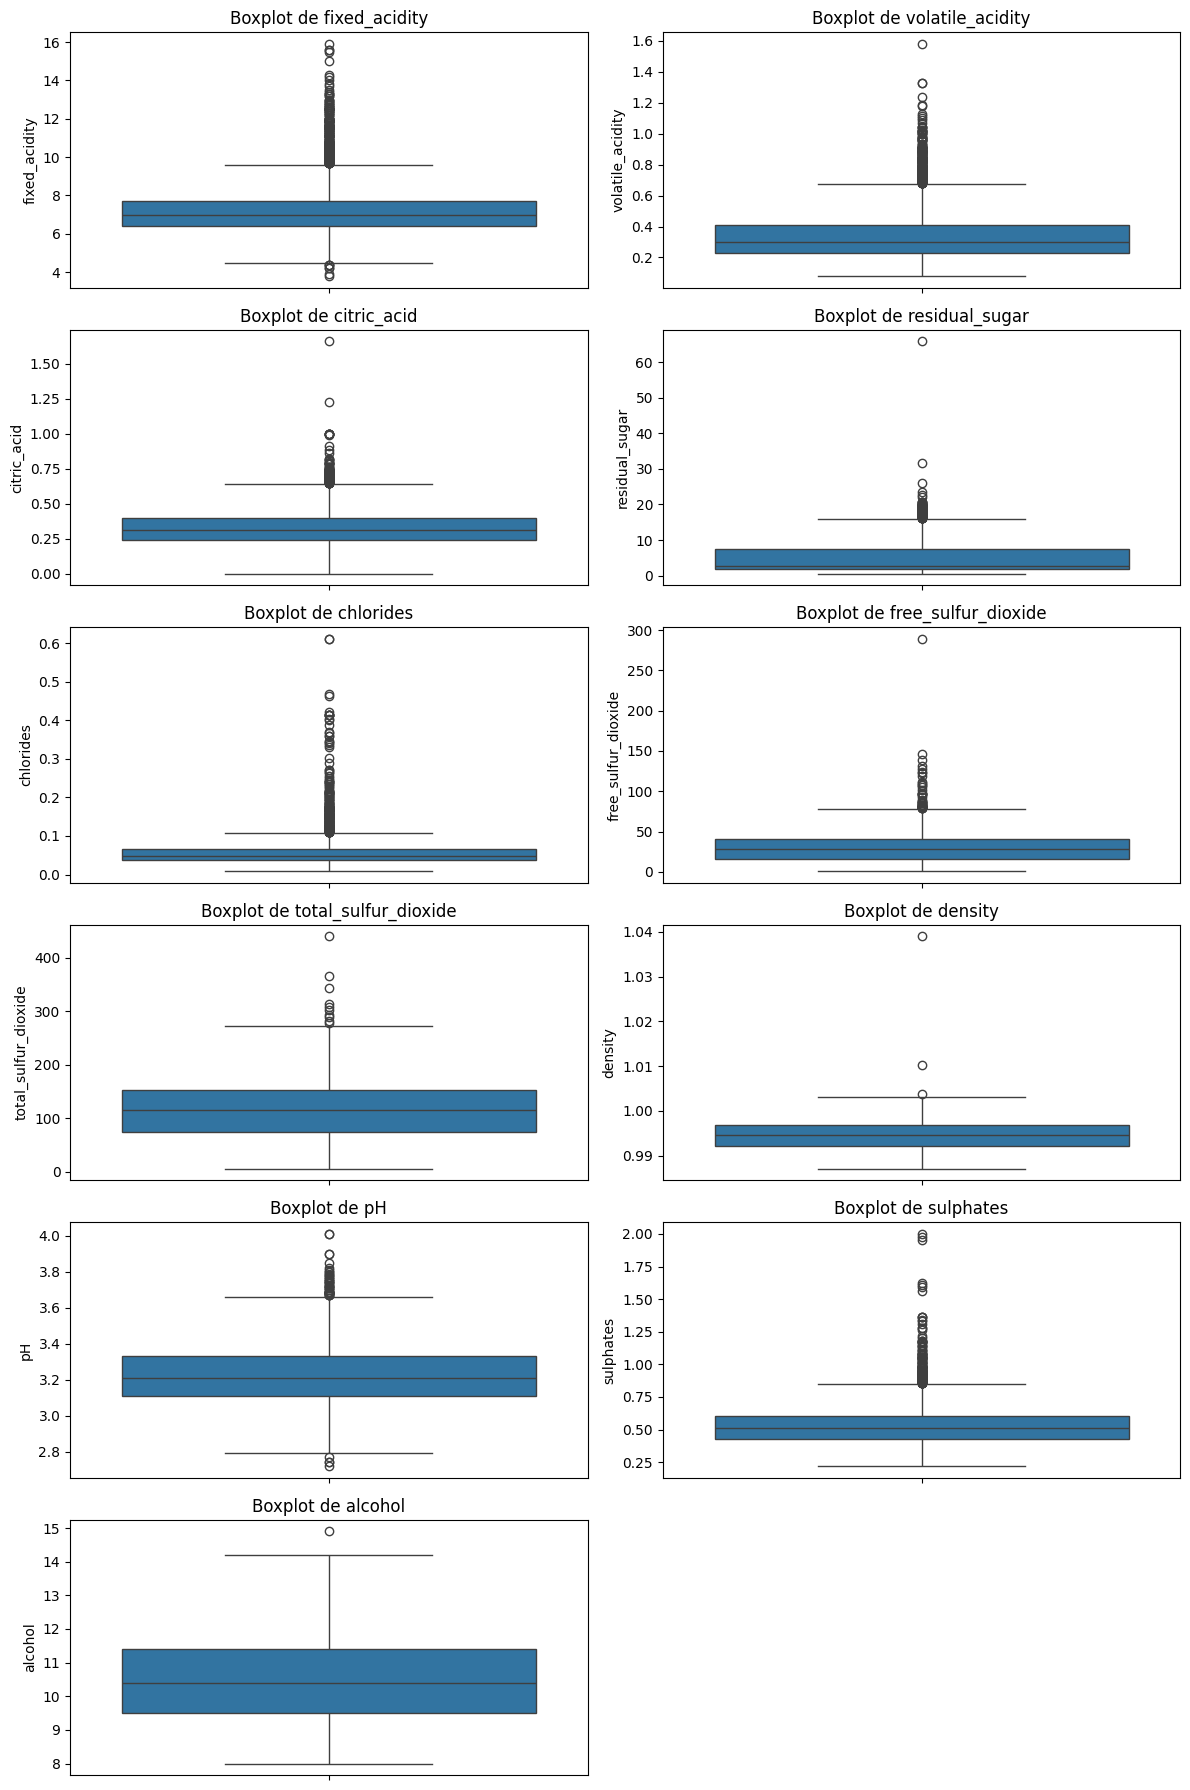

In [7]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 18))
axes = axes.flatten()

for i, columna in enumerate(variables_numericas):
    sns.boxplot(y=datos[columna], ax=axes[i], color='C0')
    axes[i].set_title(f'Boxplot de {columna}')
    axes[i].set_ylabel(columna)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
outlier_indices = {}

for var in variables_numericas:
    Q1 = datos[var].quantile(0.25)
    Q3 = datos[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = datos[(datos[var] < lower_bound) | (datos[var] > upper_bound)].index.tolist()
    outlier_indices[var] = outliers

resumen_outliers = pd.DataFrame({
    'Variable': list(outlier_indices.keys()),
    'N_outliers': [len(v) for v in outlier_indices.values()],
    'Porcentaje_outliers': [round(len(v) / len(datos) * 100, 2) for v in outlier_indices.values()]
}).sort_values('Porcentaje_outliers', ascending=False)

display(resumen_outliers)

all_outlier_indices = [idx for indices in outlier_indices.values() for idx in indices]
outlier_counts = Counter(all_outlier_indices)
repeated_outliers = {idx: count for idx, count in outlier_counts.items() if count > 1}
print(f"Observaciones que son outliers en más de una variable: {len(repeated_outliers)}")

,Variable,N_outliers,Porcentaje_outliers
0,fixed_acidity,304,5.72
1,volatile_acidity,279,5.25
4,chlorides,237,4.46
9,sulphates,163,3.07
2,citric_acid,143,2.69
3,residual_sugar,141,2.65
8,pH,49,0.92
5,free_sulfur_dioxide,44,0.83
6,total_sulfur_dioxide,10,0.19
7,density,3,0.06


Observaciones que son outliers en más de una variable: 240


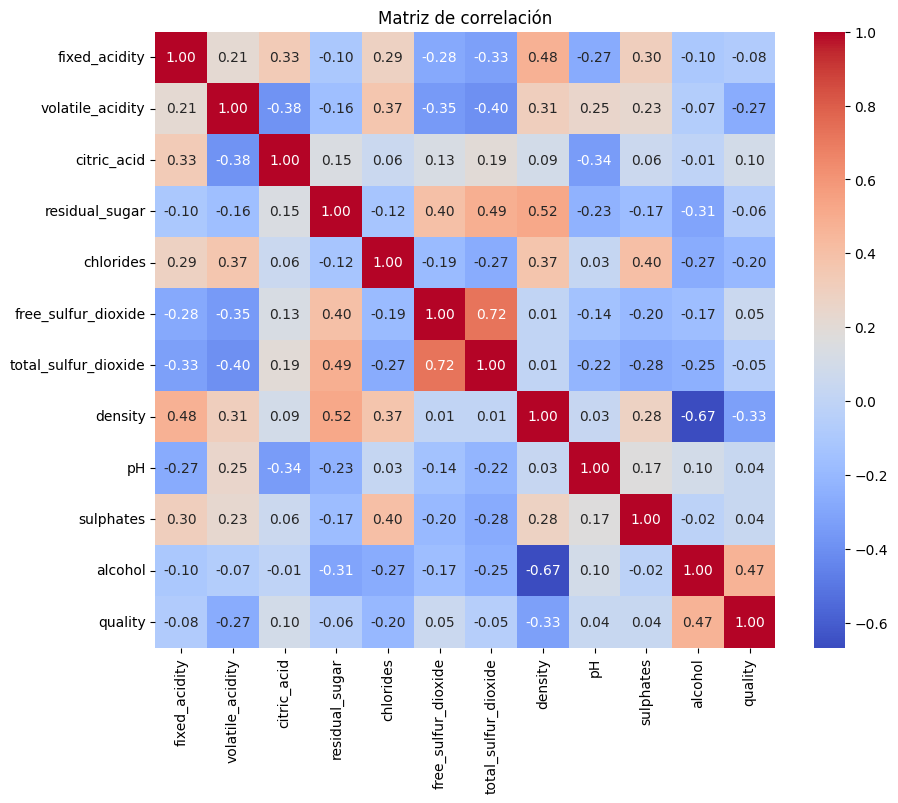

,quality
alcohol,0.469216
citric_acid,0.097926
free_sulfur_dioxide,0.054199
sulphates,0.042040
pH,0.039789
total_sulfur_dioxide,-0.050183
residual_sugar,-0.056824
fixed_acidity,-0.080190
chlorides,-0.201960
volatile_acidity,-0.265354


In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(datos.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

corr_quality = datos.corr(numeric_only=True)[['quality']].drop(index='quality').sort_values(by='quality', ascending=False)
display(corr_quality)

La matriz de correlación muestra que `alcohol` es la variable con mayor correlación positiva con la calidad del vino. Por el contrario, variables como `density`, `volatile_acidity` y `chlorides` presentan correlaciones negativas con `quality`. Aunque las correlaciones no implican causalidad, sí proporcionan una primera idea de qué variables pueden ser útiles para la predicción.

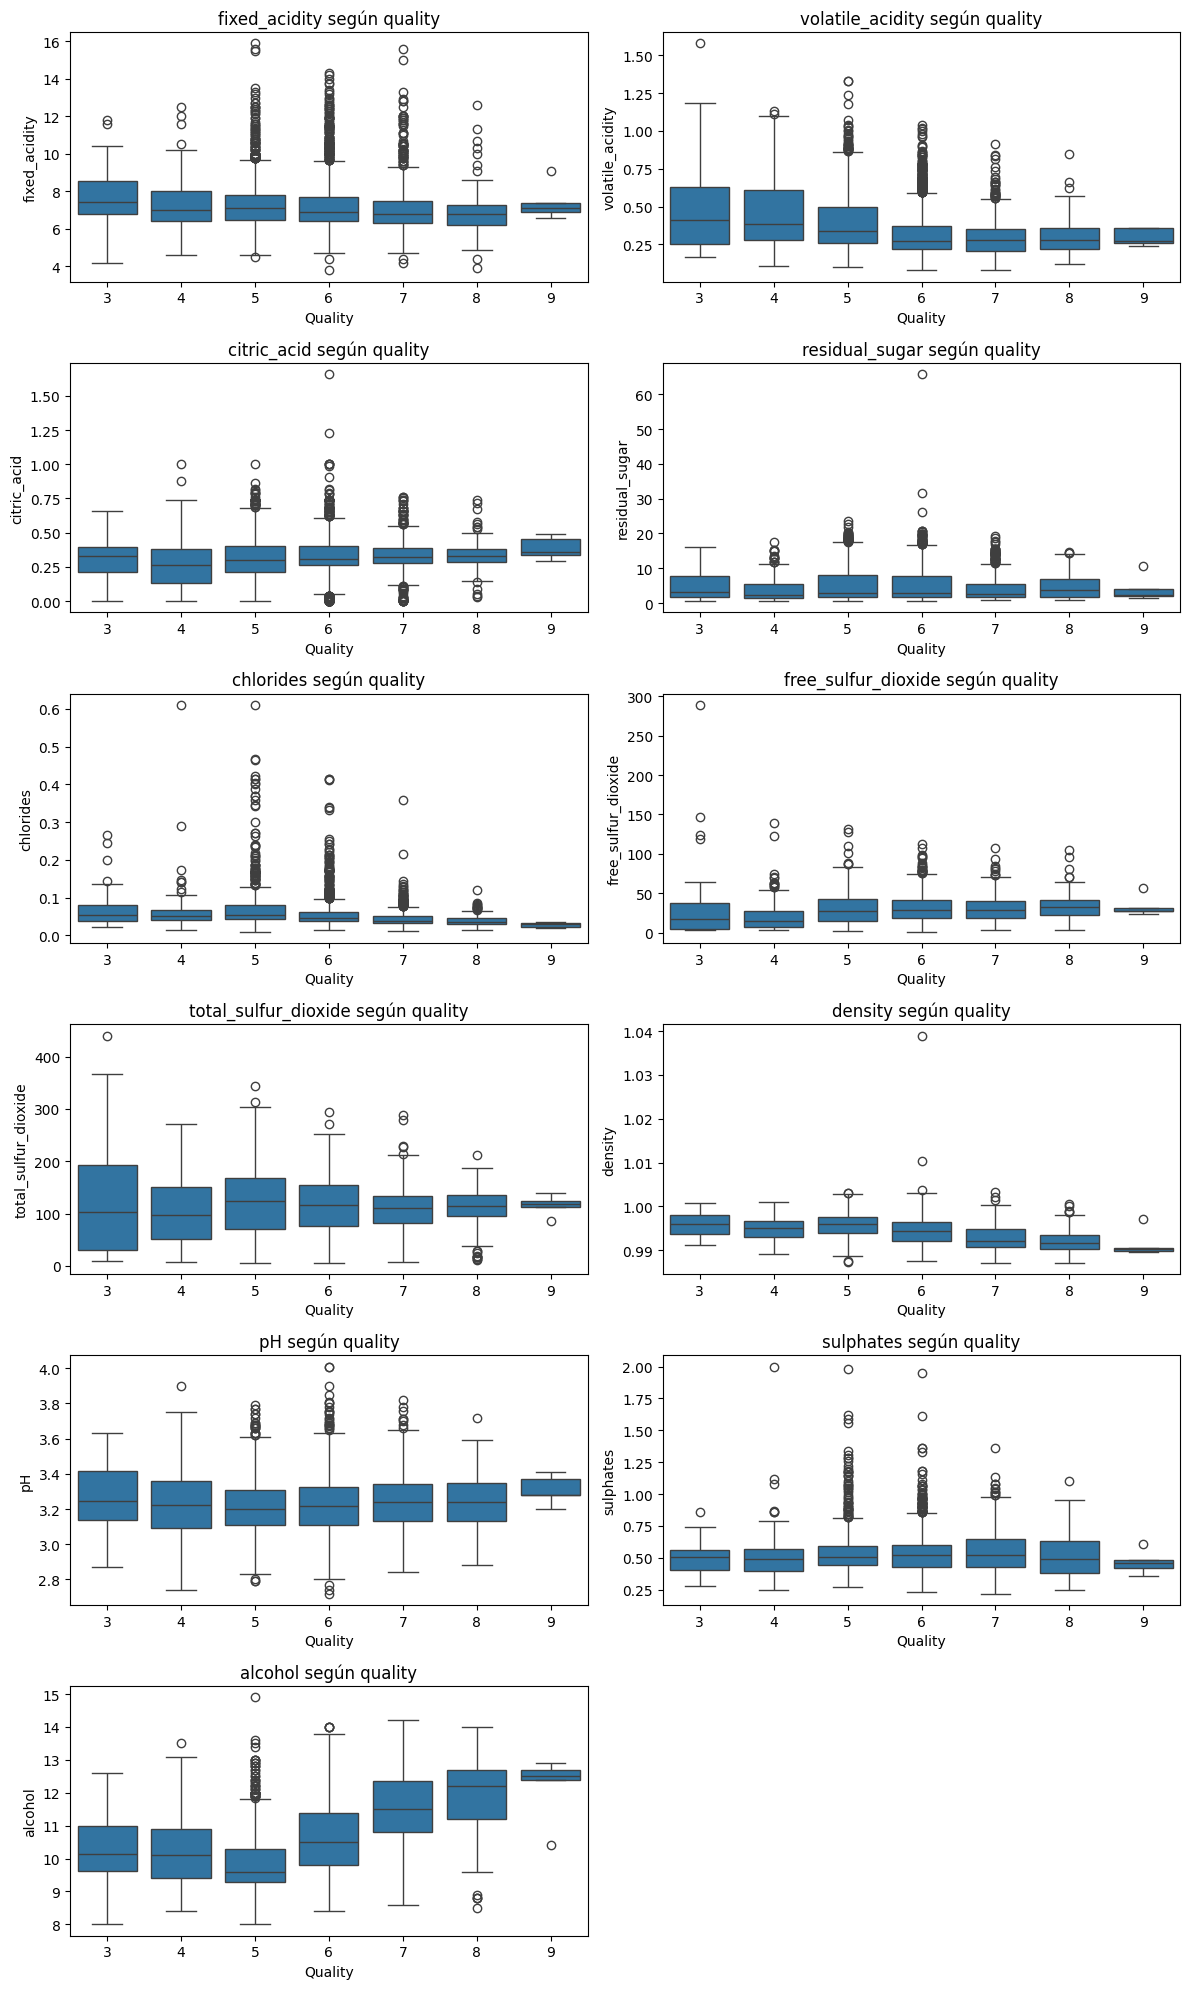

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 20))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    sns.boxplot(x='quality', y=var, data=datos, ax=axes[i], order=classes, color='C0')
    axes[i].set_title(f'{var} según quality')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(var)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
resultados_kw = []

for var in variables_numericas:
    grupos = [datos.loc[datos['quality'] == q, var].dropna() for q in classes]
    stat, p = stats.kruskal(*grupos)
    resultados_kw.append({
        'Variable': var,
        'Estadístico Kruskal-Wallis': stat,
        'p-valor': p
    })

resultados_kw = pd.DataFrame(resultados_kw).sort_values(by='p-valor')
display(resultados_kw)

,Variable,Estadístico Kruskal-Wallis,p-valor
10,alcohol,1333.407146,6.345351e-285
7,density,727.710025,6.353160e-154
4,chlorides,534.982411,2.437147e-112
1,volatile_acidity,384.019295,7.610430e-80
5,free_sulfur_dioxide,113.403262,3.947036e-22
2,citric_acid,76.109307,2.268163e-14
0,fixed_acidity,65.743441,3.040998e-12
6,total_sulfur_dioxide,52.933241,1.210176e-09
3,residual_sugar,36.960466,1.792413e-06
8,pH,25.082401,3.296646e-04


## 4. Preprocesado, selección de variables y modelos candidatos

Se utiliza `SelectKBest` dentro del pipeline para que la selección de variables se realice únicamente con los datos de entrenamiento de cada fold, evitando fuga de información.

In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, variables_numericas)
    ],
    remainder='drop'
)

# Valores de k para selección de variables. 'all' equivale a no descartar ninguna.
k_values = [3, 5, 8, 'all']

print("Preprocesador y selección de variables definidos.")

Preprocesador y selección de variables definidos.


Se consideran cuatro modelos de clasificación supervisada. La Regresión Logística se utiliza como modelo lineal base; KNN permite evaluar un enfoque basado en proximidad entre observaciones; SVM con kernel RBF permite modelar fronteras de decisión no lineales; y Random Forest se incluye como modelo ensemble basado en la combinación de múltiples árboles de decisión. Todos los modelos se integran en pipelines junto con el preprocesado y la selección de variables para evitar fuga de información durante la validación cruzada.

In [13]:
models = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('preprocessing', preprocessor),
            ('select', SelectKBest(score_func=f_classif)),
            ('model', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE))
        ]),
        'param_distributions': {
            'select__k': k_values,
            'model__C': np.logspace(-2, 2, 8),
            'model__class_weight': [None, 'balanced']
        }
    },
    'KNN': {
        'pipeline': Pipeline([
            ('preprocessing', preprocessor),
            ('select', SelectKBest(score_func=f_classif)),
            ('model', KNeighborsClassifier())
        ]),
        'param_distributions': {
            'select__k': k_values,
            'model__n_neighbors': [5, 9, 15, 21, 31],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2]
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('preprocessing', preprocessor),
            ('select', SelectKBest(score_func=f_classif)),
            ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
        ]),
        'param_distributions': {
            'select__k': k_values,
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2],
            'model__max_features': ['sqrt'],
            'model__class_weight': [None, 'balanced']
        }
    },
    'SVM RBF': {
        'pipeline': Pipeline([
            ('preprocessing', preprocessor),
            ('select', SelectKBest(score_func=f_classif)),
            ('model', SVC(kernel='rbf', probability=False, cache_size=500, random_state=RANDOM_STATE))
        ]),
        'param_distributions': {
            'select__k': k_values,
            'model__C': np.logspace(-1, 2, 6),
            'model__gamma': ['scale', 0.01, 0.1, 1],
            'model__class_weight': [None, 'balanced']
        }
    }
}

print(f"Modelos definidos: {list(models.keys())}")

Modelos definidos: ['Logistic Regression', 'KNN', 'Random Forest', 'SVM RBF']


## 5. Nested Cross-Validation para optimización y selección del mejor modelo

En esta sección se utiliza validación cruzada anidada para comparar los modelos candidatos y seleccionar el mejor modelo de forma robusta. La validación cruzada interna se emplea para optimizar los hiperparámetros y seleccionar el número de variables mediante `SelectKBest`, mientras que la validación cruzada externa permite estimar el rendimiento del modelo sobre datos no utilizados en la optimización.

La métrica principal utilizada es `f1_macro`, ya que la variable respuesta `quality` presenta un desbalanceo notable entre clases. Esta métrica calcula el F1 de cada clase y posteriormente realiza la media, dando el mismo peso a todas las clases.

In [14]:
scoring_metric = 'f1_macro'

# Con 5 folds externos se obtiene una estimación más estable que con 3 folds.
# No se usa 5x5 porque la clase 9 tiene solo 5 observaciones,
# y dentro de cada fold externo quedarían muy pocos ejemplos para la CV interna.
n_iter_search = 6

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print(f"Métrica principal: {scoring_metric}")
print(f"RandomizedSearchCV: {n_iter_search} combinaciones por modelo y fold externo")
print("Nested CV: 5 folds externos y 3 folds internos")

Métrica principal: f1_macro
RandomizedSearchCV: 6 combinaciones por modelo y fold externo
Nested CV: 5 folds externos y 3 folds internos


In [15]:
def get_scores_for_curves(estimator, X_test):
    """Devuelve probabilidades o puntuaciones para curvas ROC/PR."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_test)
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_test)
    return None


def selected_features_from_pipeline(best_model, original_features):
    """Extrae las variables seleccionadas por SelectKBest dentro del pipeline."""
    selector = best_model.named_steps.get('select')
    if selector is None or getattr(selector, 'k', None) == 'all':
        return list(original_features)
    mask = selector.get_support()
    return list(np.array(original_features)[mask])


def nested_cv_single_model(model_name, model_info, X, y, outer_cv, inner_cv, scoring_metric='f1_macro', n_iter_search=4):
    results = []
    best_params_records = []
    selected_features_records = []
    oof_records = []
    fitted_outer_models = []

    print("=" * 80)
    print(f"Modelo: {model_name}")

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
        y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]

        random_search = RandomizedSearchCV(
            estimator=model_info['pipeline'],
            param_distributions=model_info['param_distributions'],
            n_iter=n_iter_search,
            scoring=scoring_metric,
            cv=inner_cv,
            n_jobs=1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=0,
            error_score='raise'
        )

        random_search.fit(X_train_outer, y_train_outer)

        best_model = random_search.best_estimator_
        y_pred_outer = best_model.predict(X_test_outer)
        y_score_outer = get_scores_for_curves(best_model, X_test_outer)

        fold_f1 = f1_score(y_test_outer, y_pred_outer, average='macro')
        fold_accuracy = accuracy_score(y_test_outer, y_pred_outer)

        results.append({
            'model': model_name,
            'fold': fold,
            'f1_macro': fold_f1,
            'accuracy': fold_accuracy
        })

        best_params_records.append({
            'model': model_name,
            'fold': fold,
            'best_inner_cv_score': random_search.best_score_,
            'best_params': random_search.best_params_
        })

        selected_features_records.append({
            'model': model_name,
            'fold': fold,
            'selected_features': selected_features_from_pipeline(best_model, variables_numericas)
        })

        if y_score_outer is not None:
            oof_records.append({
                'fold': fold,
                'test_index': test_idx,
                'y_true': y_test_outer.to_numpy(),
                'y_score': y_score_outer,
                'classes': best_model.named_steps['model'].classes_
            })

        fitted_outer_models.append(best_model)

        print(f"Fold externo {fold} | F1-macro = {fold_f1:.4f} | Accuracy = {fold_accuracy:.4f}")

    results_df = pd.DataFrame(results)
    best_params_df = pd.DataFrame(best_params_records)
    selected_features_df = pd.DataFrame(selected_features_records)

    summary_df = pd.DataFrame({
        'model': [model_name],
        'f1_macro_mean': [results_df['f1_macro'].mean()],
        'f1_macro_std': [results_df['f1_macro'].std()],
        'accuracy_mean': [results_df['accuracy'].mean()],
        'accuracy_std': [results_df['accuracy'].std()]
    })

    return {
        'results_df': results_df,
        'best_params_df': best_params_df,
        'selected_features_df': selected_features_df,
        'summary_df': summary_df,
        'oof_records': oof_records,
        'fitted_outer_models': fitted_outer_models
    }

In [16]:
all_outputs = {}

for model_name, model_info in models.items():
    all_outputs[model_name] = nested_cv_single_model(
        model_name=model_name,
        model_info=model_info,
        X=X,
        y=y,
        outer_cv=outer_cv,
        inner_cv=inner_cv,
        scoring_metric=scoring_metric,
        n_iter_search=n_iter_search
    )

summary_df = pd.concat([out['summary_df'] for out in all_outputs.values()], ignore_index=True)
summary_df = summary_df.sort_values(by='f1_macro_mean', ascending=False).reset_index(drop=True)

display(summary_df)

Modelo: Logistic Regression
Fold externo 1 | F1-macro = 0.2228 | Accuracy = 0.5517
Fold externo 2 | F1-macro = 0.2165 | Accuracy = 0.3120
Fold externo 3 | F1-macro = 0.2705 | Accuracy = 0.5517
Fold externo 4 | F1-macro = 0.2267 | Accuracy = 0.5560
Fold externo 5 | F1-macro = 0.2634 | Accuracy = 0.5579
Modelo: KNN
Fold externo 1 | F1-macro = 0.2280 | Accuracy = 0.5573
Fold externo 2 | F1-macro = 0.2374 | Accuracy = 0.5329
Fold externo 3 | F1-macro = 0.2504 | Accuracy = 0.5451
Fold externo 4 | F1-macro = 0.2445 | Accuracy = 0.4798
Fold externo 5 | F1-macro = 0.2407 | Accuracy = 0.5579
Modelo: Random Forest
Fold externo 1 | F1-macro = 0.2660 | Accuracy = 0.5893
Fold externo 2 | F1-macro = 0.3002 | Accuracy = 0.4756
Fold externo 3 | F1-macro = 0.2907 | Accuracy = 0.4793
Fold externo 4 | F1-macro = 0.2770 | Accuracy = 0.4760
Fold externo 5 | F1-macro = 0.3010 | Accuracy = 0.4967
Modelo: SVM RBF
Fold externo 1 | F1-macro = 0.2670 | Accuracy = 0.4981
Fold externo 2 | F1-macro = 0.2537 | Accur

,model,f1_macro_mean,f1_macro_std,accuracy_mean,accuracy_std
0,Random Forest,0.286956,0.015205,0.503378,0.048800
1,SVM RBF,0.251938,0.019079,0.485895,0.018631
2,KNN,0.240195,0.008357,0.534594,0.032314
3,Logistic Regression,0.239979,0.025015,0.505848,0.108381


In [17]:
from scipy.stats import t

def mean_std_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = values.mean()
    std = values.std(ddof=1)
    se = std / np.sqrt(n)
    t_crit = t.ppf((1 + confidence) / 2, df=n - 1)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se
    return mean, std, ci_low, ci_high, t_crit

ci_records = []

for model_name, out in all_outputs.items():
    scores = out["results_df"]["f1_macro"].values
    accs = out["results_df"]["accuracy"].values

    f1_mean, f1_std, f1_ci_low, f1_ci_high, t_crit = mean_std_ci(scores)
    acc_mean, acc_std, acc_ci_low, acc_ci_high, _ = mean_std_ci(accs)

    ci_records.append({
        "model": model_name,
        "n_outer_folds": len(scores),
        "t_crit_95": t_crit,
        "f1_macro_mean": f1_mean,
        "f1_macro_std": f1_std,
        "f1_macro_ci95_low": f1_ci_low,
        "f1_macro_ci95_high": f1_ci_high,
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "accuracy_ci95_low": acc_ci_low,
        "accuracy_ci95_high": acc_ci_high
    })

summary_ci_df = pd.DataFrame(ci_records)
summary_ci_df = summary_ci_df.sort_values(by="f1_macro_mean", ascending=False).reset_index(drop=True)

numeric_cols = summary_ci_df.select_dtypes(include="number").columns
summary_ci_df[numeric_cols] = summary_ci_df[numeric_cols].round(4)

display(summary_ci_df)

,model,n_outer_folds,t_crit_95,f1_macro_mean,f1_macro_std,f1_macro_ci95_low,f1_macro_ci95_high,accuracy_mean,accuracy_std,accuracy_ci95_low,accuracy_ci95_high
0,Random Forest,5,2.7764,0.2870,0.0152,0.2681,0.3058,0.5034,0.0488,0.4428,0.5640
1,SVM RBF,5,2.7764,0.2519,0.0191,0.2282,0.2756,0.4859,0.0186,0.4628,0.5090
2,KNN,5,2.7764,0.2402,0.0084,0.2298,0.2506,0.5346,0.0323,0.4945,0.5747
3,Logistic Regression,5,2.7764,0.2400,0.0250,0.2089,0.2710,0.5058,0.1084,0.3713,0.6404


Según los resultados de la validación cruzada anidada, el modelo con mejor rendimiento medio en términos de F1-macro es Random Forest, con un valor medio de 0.2870. Aunque KNN y Logistic Regression obtienen una accuracy media ligeramente superior, se prioriza F1-macro debido al desbalanceo existente en la variable respuesta `quality`. Esta métrica permite valorar mejor el comportamiento del modelo en todas las clases, no solo en las clases mayoritarias.

Al calcular intervalos de confianza al 95 % mediante la t de Student, se observa que el intervalo de Random Forest se solapa parcialmente con los de SVM RBF y Logistic Regression, aunque no con el de KNN.

In [18]:
best_model_name = summary_df.loc[0, 'model']
print(f"Mejor modelo según F1-macro medio en Nested CV: {best_model_name}")

best_params_all = all_outputs[best_model_name]['best_params_df']
selected_features_all = all_outputs[best_model_name]['selected_features_df']

print("\nMejores parámetros en cada fold externo:")
display(best_params_all)

print("\nVariables seleccionadas en cada fold externo:")
display(selected_features_all)

Mejor modelo según F1-macro medio en Nested CV: Random Forest

Mejores parámetros en cada fold externo:


,model,fold,best_inner_cv_score,best_params
0,Random Forest,1,0.258120,"{'select__k': 'all', 'model__n_estimators': 30..."
1,Random Forest,2,0.259552,"{'select__k': 5, 'model__n_estimators': 300, '..."
2,Random Forest,3,0.255990,"{'select__k': 5, 'model__n_estimators': 300, '..."
3,Random Forest,4,0.273876,"{'select__k': 5, 'model__n_estimators': 300, '..."
4,Random Forest,5,0.258011,"{'select__k': 5, 'model__n_estimators': 300, '..."



Variables seleccionadas en cada fold externo:


,model,fold,selected_features
0,Random Forest,1,"[fixed_acidity, volatile_acidity, citric_acid,..."
1,Random Forest,2,"[volatile_acidity, chlorides, free_sulfur_diox..."
2,Random Forest,3,"[volatile_acidity, chlorides, free_sulfur_diox..."
3,Random Forest,4,"[volatile_acidity, chlorides, free_sulfur_diox..."
4,Random Forest,5,"[volatile_acidity, chlorides, free_sulfur_diox..."


In [19]:
def params_to_tuple(params):
    """Convierte un diccionario de hiperparámetros en una tupla ordenada para poder contar repeticiones."""
    return tuple(sorted(params.items()))

def tuple_to_params(params_tuple):
    """Convierte de nuevo la tupla ordenada en diccionario."""
    return dict(params_tuple)

params_counter = Counter(
    params_to_tuple(params) for params in best_params_all["best_params"]
)

modal_params_tuple, modal_params_count = params_counter.most_common(1)[0]
modal_best_params = tuple_to_params(modal_params_tuple)

print("Moda de hiperparámetros del mejor modelo:")
print(modal_best_params)
print(f"\nFrecuencia de la configuración modal: {modal_params_count} de {len(best_params_all)} folds externos")

Moda de hiperparámetros del mejor modelo:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300, 'select__k': 5}

Frecuencia de la configuración modal: 4 de 5 folds externos


In [20]:
print("Variables seleccionadas por fold externo:")

for _, row in selected_features_all.iterrows():
    print(f"\nFold {row['fold']}:")
    for feature in row['selected_features']:
        print(f" - {feature}")

Variables seleccionadas por fold externo:

Fold 1:
 - fixed_acidity
 - volatile_acidity
 - citric_acid
 - residual_sugar
 - chlorides
 - free_sulfur_dioxide
 - total_sulfur_dioxide
 - density
 - pH
 - sulphates
 - alcohol

Fold 2:
 - volatile_acidity
 - chlorides
 - free_sulfur_dioxide
 - density
 - alcohol

Fold 3:
 - volatile_acidity
 - chlorides
 - free_sulfur_dioxide
 - density
 - alcohol

Fold 4:
 - volatile_acidity
 - chlorides
 - free_sulfur_dioxide
 - density
 - alcohol

Fold 5:
 - volatile_acidity
 - chlorides
 - free_sulfur_dioxide
 - density
 - alcohol


In [21]:
from collections import Counter

all_selected_features = []

for features in selected_features_all['selected_features']:
    all_selected_features.extend(features)

feature_selection_frequency = pd.DataFrame(
    Counter(all_selected_features).items(),
    columns=['Variable', 'Frecuencia_seleccion']
).sort_values(by='Frecuencia_seleccion', ascending=False)

display(feature_selection_frequency)

,Variable,Frecuencia_seleccion
1,volatile_acidity,5
5,free_sulfur_dioxide,5
4,chlorides,5
10,alcohol,5
7,density,5
2,citric_acid,1
0,fixed_acidity,1
6,total_sulfur_dioxide,1
3,residual_sugar,1
8,pH,1


La selección de variables se realizó dentro de cada fold de la validación cruzada, evitando así fuga de información. En el caso del modelo seleccionado, Random Forest, el valor `select__k = 5` fue elegido en cuatro de los cinco folds externos, mientras que en un fold se seleccionó la opción `all`. Por tanto, el procedimiento tiende mayoritariamente a trabajar con un subconjunto reducido de variables.

Las variables `volatile_acidity`, `chlorides`, `free_sulfur_dioxide`, `density` y `alcohol` aparecieron seleccionadas en los cinco folds externos. Esto indica que son las variables más estables dentro del proceso de selección. Además, este resultado es coherente con el EDA, ya que varias de ellas mostraban relación con la variable respuesta `quality`, especialmente `alcohol`, `density` y `volatile_acidity`. Las restantes variables solo aparecen en el fold en el que se seleccionó `k='all'`, por lo que no se consideran tan estables.

## 6. Evaluación out-of-fold del mejor modelo y entrenamiento final

Tras seleccionar el mejor algoritmo mediante Nested CV, se construye un pipeline con la configuración modal de hiperparámetros obtenida en los folds externos. Para evaluar el modelo de forma coherente con la validación cruzada, se utilizan predicciones out-of-fold mediante `cross_val_predict` y el mismo `outer_cv`. De esta forma, cada observación es predicha por un modelo que no ha sido entrenado con ella.

Posteriormente, el modelo final se entrena sobre todo el conjunto de datos utilizando la configuración modal, quedando disponible como modelo único final.

In [22]:
# Pipeline con la configuración modal obtenida en la Nested CV
pipe_con_moda = clone(models[best_model_name]["pipeline"])
pipe_con_moda.set_params(**modal_best_params)

print("Hiperparámetros finales usados en el pipeline con moda:")
print(modal_best_params)

print("\nVariables seleccionadas por la configuración modal:")
pipe_con_moda_features = clone(models[best_model_name]["pipeline"])
pipe_con_moda_features.set_params(**modal_best_params)
pipe_con_moda_features.fit(X, y)

for var in selected_features_from_pipeline(pipe_con_moda_features, variables_numericas):
    print(f"- {str(var)}")

# Predicciones out-of-fold: cada observación se predice con un modelo
# que no ha sido entrenado con ella.
y_pred_oof = cross_val_predict(
    pipe_con_moda,
    X,
    y,
    cv=outer_cv,
    n_jobs=-1
)

# Probabilidades out-of-fold para curvas ROC/PR
y_score_oof = cross_val_predict(
    pipe_con_moda,
    X,
    y,
    cv=outer_cv,
    method="predict_proba",
    n_jobs=-1
)

print("\nEvaluación out-of-fold del modelo con hiperparámetros modales")
print("F1-macro OOF:", round(f1_score(y, y_pred_oof, average="macro"), 4))
print("Accuracy OOF:", round(accuracy_score(y, y_pred_oof), 4))

print("\nInforme de clasificación OOF:")
print(classification_report(y, y_pred_oof))

Hiperparámetros finales usados en el pipeline con moda:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300, 'select__k': 5}

Variables seleccionadas por la configuración modal:
- volatile_acidity
- chlorides
- free_sulfur_dioxide
- density
- alcohol

Evaluación out-of-fold del modelo con hiperparámetros modales
F1-macro OOF: 0.2851
Accuracy OOF: 0.4818

Informe de clasificación OOF:
              precision    recall  f1-score   support

           3       0.23      0.10      0.14        30
           4       0.22      0.27      0.24       206
           5       0.57      0.66      0.61      1751
           6       0.56      0.37      0.45      2323
           7       0.36      0.55      0.43       855
           8       0.12      0.13      0.12       148
           9       0.00      0.00      0.00         5

    accuracy                           0.48      531

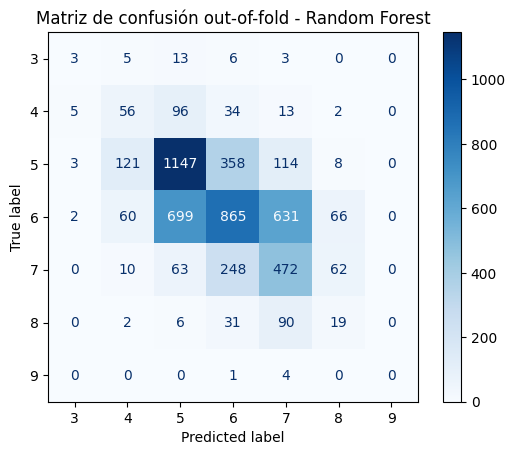

In [23]:
cm = confusion_matrix(y, y_pred_oof, labels=classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión out-of-fold - {best_model_name}")
plt.show()

La evaluación out-of-fold del modelo Random Forest con hiperparámetros modales es coherente con los resultados obtenidos durante la validación cruzada anidada. Al utilizar `cross_val_predict` con el mismo `outer_cv`, cada observación se evalúa mediante un modelo que no ha sido entrenado con ella, evitando así una evaluación optimista basada en un split adicional.

La matriz de confusión muestra que el modelo clasifica mejor las calidades centrales, especialmente las clases 5, 6 y 7, que son las más frecuentes en el conjunto de datos. En cambio, las clases extremas, como 3 y 9, presentan un rendimiento muy bajo debido a su escasa representación en la muestra.

También se observa que muchas de las confusiones se producen entre calidades próximas, por ejemplo entre 5 y 6 o entre 6 y 7. Esto es razonable, ya que la variable `quality` tiene una naturaleza ordinal y las diferencias entre calidades consecutivas pueden ser pequeñas.

## 7. Curva PR/ROC y punto óptimo de funcionamiento

Como la variable respuesta es multiclase y está desbalanceada, se usa una curva Precision-Recall micro-promediada. El punto óptimo se elige maximizando el F1 calculado sobre precisión y recall para todos los pares clase-observación.

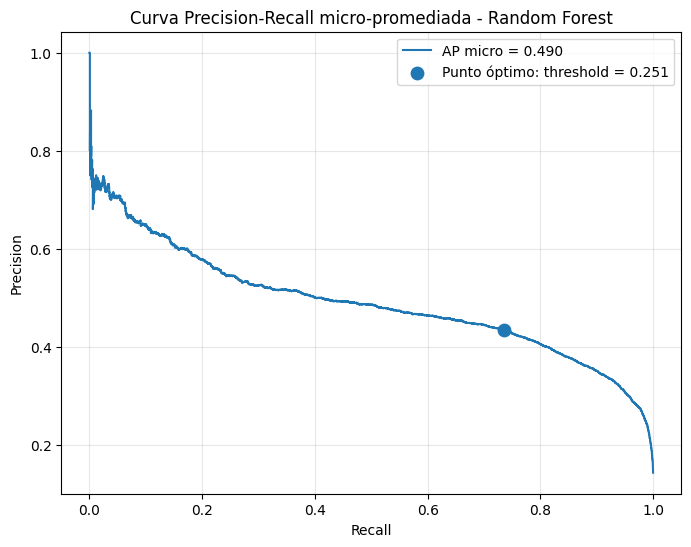

Average Precision micro: 0.4897
Umbral óptimo PR por máximo F1: 0.2511
Precision en el punto óptimo: 0.4343
Recall en el punto óptimo: 0.7362
F1 en el punto óptimo: 0.5463


In [24]:
classes = np.sort(y.unique())
y_true_bin = label_binarize(y, classes=classes)

precision, recall, thresholds_pr = precision_recall_curve(
    y_true_bin.ravel(),
    y_score_oof.ravel()
)

avg_precision_micro = average_precision_score(
    y_true_bin,
    y_score_oof,
    average="micro"
)

# El último punto de precision_recall_curve no tiene umbral asociado.
f1_values = 2 * precision[:-1] * recall[:-1] / (
    precision[:-1] + recall[:-1] + 1e-12
)

best_idx = int(np.argmax(f1_values))
best_threshold_pr = thresholds_pr[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1_pr = f1_values[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"AP micro = {avg_precision_micro:.3f}")
plt.scatter(
    best_recall,
    best_precision,
    s=80,
    label=f"Punto óptimo: threshold = {best_threshold_pr:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Curva Precision-Recall micro-promediada - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Average Precision micro: {avg_precision_micro:.4f}")
print(f"Umbral óptimo PR por máximo F1: {best_threshold_pr:.4f}")
print(f"Precision en el punto óptimo: {best_precision:.4f}")
print(f"Recall en el punto óptimo: {best_recall:.4f}")
print(f"F1 en el punto óptimo: {best_f1_pr:.4f}")

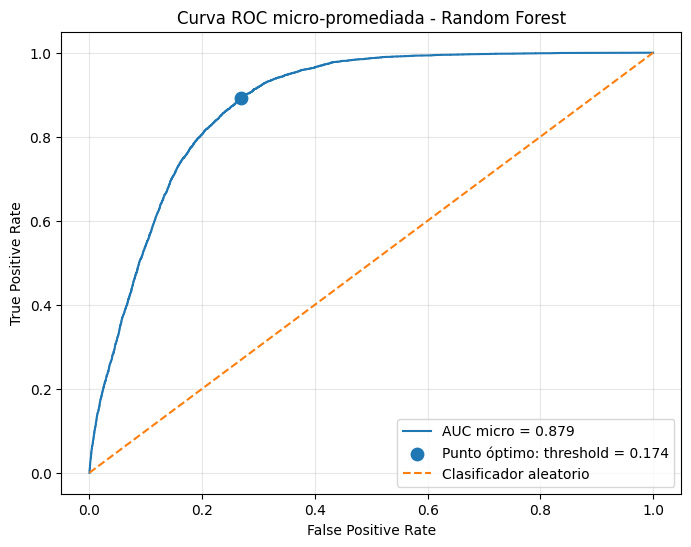

AUC ROC micro: 0.8787
Umbral óptimo ROC por índice de Youden: 0.1739
TPR en el punto óptimo: 0.8926
FPR en el punto óptimo: 0.2691


In [25]:
fpr, tpr, thresholds_roc = roc_curve(
    y_true_bin.ravel(),
    y_score_oof.ravel()
)

roc_auc_micro = auc(fpr, tpr)

youden = tpr - fpr
best_idx_roc = int(np.argmax(youden))
best_threshold_roc = thresholds_roc[best_idx_roc]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC micro = {roc_auc_micro:.3f}")
plt.scatter(
    fpr[best_idx_roc],
    tpr[best_idx_roc],
    s=80,
    label=f"Punto óptimo: threshold = {best_threshold_roc:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC micro-promediada - {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC ROC micro: {roc_auc_micro:.4f}")
print(f"Umbral óptimo ROC por índice de Youden: {best_threshold_roc:.4f}")
print(f"TPR en el punto óptimo: {tpr[best_idx_roc]:.4f}")
print(f"FPR en el punto óptimo: {fpr[best_idx_roc]:.4f}")

La curva Precision-Recall micro-promediada obtiene un Average Precision de 0.4897. El punto óptimo de funcionamiento se selecciona maximizando el valor F1, obteniendo un umbral de 0.2511. En dicho punto se alcanza una precision de 0.4343, un recall de 0.7362 y un F1 de 0.5463.

Este resultado indica que el modelo prioriza una recuperación elevada de casos frente a una precisión más moderada. Es decir, el modelo consigue detectar una proporción alta de casos relevantes, aunque a costa de introducir falsos positivos. Este comportamiento es razonable en un problema multiclase y desbalanceado como el presente, donde las clases extremas tienen muy pocas observaciones.

La curva ROC micro-promediada se incluye como análisis complementario, obteniendo un AUC de 0.8787. El punto óptimo según el índice de Youden se obtiene con un umbral de 0.1739, un TPR de 0.8926 y un FPR de 0.2691. Aunque el AUC indica una buena capacidad global de discriminación, la curva Precision-Recall se considera más informativa en este caso debido al desbalanceo de la variable respuesta.

## 8. Tablas finales para la memoria

In [26]:
# Tabla resumen de modelos
display(summary_df)

# Tabla con todos los resultados por fold
fold_results_df = pd.concat([out['results_df'] for out in all_outputs.values()], ignore_index=True)
display(fold_results_df.sort_values(['model', 'fold']))

# Tabla de mejores hiperparámetros por fold y modelo
best_params_df = pd.concat([out['best_params_df'] for out in all_outputs.values()], ignore_index=True)
display(best_params_df)

# Tabla de variables seleccionadas por fold y modelo
selected_features_df = pd.concat([out['selected_features_df'] for out in all_outputs.values()], ignore_index=True)
display(selected_features_df)

,model,f1_macro_mean,f1_macro_std,accuracy_mean,accuracy_std
0,Random Forest,0.286956,0.015205,0.503378,0.048800
1,SVM RBF,0.251938,0.019079,0.485895,0.018631
2,KNN,0.240195,0.008357,0.534594,0.032314
3,Logistic Regression,0.239979,0.025015,0.505848,0.108381


,model,fold,f1_macro,accuracy
5,KNN,1,0.228031,0.557331
6,KNN,2,0.237350,0.532895
7,KNN,3,0.250426,0.545113
8,KNN,4,0.244481,0.479774
9,KNN,5,0.240685,0.557855
0,Logistic Regression,1,0.222777,0.551692
1,Logistic Regression,2,0.216506,0.312030
2,Logistic Regression,3,0.270489,0.551692
3,Logistic Regression,4,0.226710,0.555974
4,Logistic Regression,5,0.263414,0.557855


,model,fold,best_inner_cv_score,best_params
0,Logistic Regression,1,0.225456,"{'select__k': 'all', 'model__class_weight': No..."
1,Logistic Regression,2,0.229007,"{'select__k': 'all', 'model__class_weight': 'b..."
2,Logistic Regression,3,0.224693,"{'select__k': 'all', 'model__class_weight': No..."
3,Logistic Regression,4,0.230715,"{'select__k': 'all', 'model__class_weight': No..."
4,Logistic Regression,5,0.222838,"{'select__k': 'all', 'model__class_weight': No..."
5,KNN,1,0.227920,"{'select__k': 5, 'model__weights': 'distance',..."
6,KNN,2,0.232220,"{'select__k': 5, 'model__weights': 'distance',..."
7,KNN,3,0.227521,"{'select__k': 5, 'model__weights': 'distance',..."
8,KNN,4,0.236012,"{'select__k': 3, 'model__weights': 'distance',..."
9,KNN,5,0.222086,"{'select__k': 5, 'model__weights': 'distance',..."


,model,fold,selected_features
0,Logistic Regression,1,"[fixed_acidity, volatile_acidity, citric_acid,..."
1,Logistic Regression,2,"[fixed_acidity, volatile_acidity, citric_acid,..."
2,Logistic Regression,3,"[fixed_acidity, volatile_acidity, citric_acid,..."
3,Logistic Regression,4,"[fixed_acidity, volatile_acidity, citric_acid,..."
4,Logistic Regression,5,"[fixed_acidity, volatile_acidity, citric_acid,..."
5,KNN,1,"[volatile_acidity, residual_sugar, chlorides, ..."
6,KNN,2,"[volatile_acidity, chlorides, free_sulfur_diox..."
7,KNN,3,"[volatile_acidity, chlorides, free_sulfur_diox..."
8,KNN,4,"[volatile_acidity, density, alcohol]"
9,KNN,5,"[volatile_acidity, chlorides, free_sulfur_diox..."


In [27]:
# Tabla resumen final del modelo seleccionado para la memoria
final_summary = pd.DataFrame({
    "Modelo seleccionado": [best_model_name],
    "Métrica de selección": [scoring_metric],
    "F1-macro Nested CV": [summary_df.loc[summary_df["model"] == best_model_name, "f1_macro_mean"].values[0]],
    "Accuracy Nested CV": [summary_df.loc[summary_df["model"] == best_model_name, "accuracy_mean"].values[0]],
    "F1-macro OOF": [f1_score(y, y_pred_oof, average="macro")],
    "Accuracy OOF": [accuracy_score(y, y_pred_oof)],
    "Average Precision micro": [avg_precision_micro],
    "AUC ROC micro": [roc_auc_micro]
})

numeric_cols = final_summary.select_dtypes(include="number").columns
final_summary[numeric_cols] = final_summary[numeric_cols].round(4)

display(final_summary)

,Modelo seleccionado,Métrica de selección,F1-macro Nested CV,Accuracy Nested CV,F1-macro OOF,Accuracy OOF,Average Precision micro,AUC ROC micro
0,Random Forest,f1_macro,0.287,0.5034,0.2851,0.4818,0.4897,0.8787


La tabla resume los principales resultados del modelo seleccionado. Random Forest fue elegido como mejor modelo al obtener el mayor F1-macro medio en la validación cruzada anidada. La evaluación final se realiza mediante predicciones out-of-fold con el pipeline configurado con la moda de hiperparámetros, por lo que cada observación es predicha por un modelo que no ha sido entrenado con ella.

La diferencia entre accuracy y F1-macro confirma la influencia del desbalanceo de clases. Aunque la accuracy out-of-fold es mayor que el F1-macro, este último penaliza el bajo rendimiento en las clases minoritarias. La curva Precision-Recall y la curva ROC micro-promediada se calculan también a partir de las probabilidades out-of-fold, manteniendo así la coherencia entre la matriz de confusión, las métricas finales y las curvas.

In [28]:
# Entrenamiento del modelo final único sobre todo el conjunto de datos
# con la configuración modal. Este modelo queda disponible para despliegue
# o para extraer variables seleccionadas/importancias.
final_model = clone(models[best_model_name]["pipeline"])
final_model.set_params(**modal_best_params)
final_model.fit(X, y)

# Nombres de las variables después del preprocesado
feature_names_preprocessed = final_model.named_steps["preprocessing"].get_feature_names_out()

# Limpiar nombres, quitando el prefijo del ColumnTransformer si aparece
feature_names_clean = [
    name.split("__")[-1] for name in feature_names_preprocessed
]

# Máscara de variables seleccionadas por SelectKBest
selected_mask = final_model.named_steps["select"].get_support()

# Lista final de variables seleccionadas
final_selected_features = [
    feature for feature, selected in zip(feature_names_clean, selected_mask) if selected
]

print("Variables seleccionadas en el modelo final entrenado sobre todo el dataset:")
for var in final_selected_features:
    print(f"- {var}")

Variables seleccionadas en el modelo final entrenado sobre todo el dataset:
- volatile_acidity
- chlorides
- free_sulfur_dioxide
- density
- alcohol


In [29]:
final_features_df = pd.DataFrame({
    "Variable seleccionada": [str(var) for var in final_selected_features]
})

display(final_features_df)

,Variable seleccionada
0,volatile_acidity
1,chlorides
2,free_sulfur_dioxide
3,density
4,alcohol
